# 05 — Leave-One-Bearing-Out Evaluation Across NASA IMS Sets 1, 2, 3

**Goal.** Replicate the Random Forest and 1D-CNN models from notebooks 03–04 under a strict **Leave-One-Bearing-Out (LOBO)** cross-validation protocol over all 12 bearings in NASA IMS — and report how the headline metrics change when measured under the more honest evaluation that Darlami & Awasthi 2026 (corpus paper #18) use.

**Why this matters.** Set 2's stratified split (notebooks 03–04) puts windows from the same bearing's same one-second snapshot into both training and test, separated only by the random shuffle. The model never has to generalise to a *new bearing it has never seen*. LOBO does exactly that: hold one bearing out, train on the other 11, evaluate on the held-out. Repeat 12 times. The mean ± standard deviation of MCC across the 12 folds is the realistic cross-asset generalisation estimate — and gives a direct number to compare against Darlami's published **MCC = 0.636 ± 0.285**.

**Setup.**
- 12 bearings = 4 (Set 1, dual-channel, take channel 1) + 4 (Set 2) + 4 (Set 3).
- Documented failures: Set 1 B3 (inner race), Set 1 B4 (ball element), Set 2 B1 (outer race), Set 3 B3 (outer race). The other 8 bearings are Normal throughout.
- 946,400 (file × bearing × window) feature rows; same 6-D physics-informed features as notebook 02, same EWMA-based 3-class labelling per failure bearing.
- Same models as notebooks 03–04: Random Forest (300 trees, class-weighted) and 1D-CNN (~110k params).

**Expected outcome.** MCC drops substantially from notebook 03/04's Set-2 numbers (RF 0.835, CNN 0.871) because (a) cross-bearing generalisation is genuinely harder, (b) different failure modes (outer race vs inner race vs ball) excite different signature patterns, (c) Set 3's much longer duration (6,324 files vs 984 in Set 2) shifts the class balance toward heavy Normal. Target: land within Darlami's 0.636 ± 0.285 range.

In [1]:
from __future__ import annotations

import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import matthews_corrcoef, f1_score, average_precision_score
from sklearn.preprocessing import label_binarize

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

DEVICE = torch.device("mps") if torch.backends.mps.is_available() else (
    torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
)
print(f"PyTorch {torch.__version__} | device: {DEVICE}")

torch.manual_seed(42)
np.random.seed(42)

NB_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = NB_DIR.parent
FIG_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR.mkdir(exist_ok=True)

PyTorch 2.10.0.dev20251110 | device: mps


## 1. Load cached feature matrix and raw windows

Both produced by helper scripts in `notebooks/`:
- `extract_all_features.py` → `data/processed/all_sets_features.parquet` (~45 MB)
- `extract_raw_windows.py` → `data/processed/raw_windows.npy` (~3 GB) + metadata parquet

In [2]:
features_df = pd.read_parquet(PROCESSED_DIR / "all_sets_features.parquet")
print(f"features: {features_df.shape}")
print(f"bearing_uid distribution:")
print(features_df["bearing_uid"].value_counts().sort_index())
print()
print(f"state distribution:")
print(features_df["state"].value_counts().sort_index().rename({0: "Normal", 1: "Degraded", 2: "Critical"}))

features: (946400, 13)
bearing_uid distribution:
bearing_uid
11     53900
12     53900
13     53900
14     53900
21     24600
22     24600
23     24600
24     24600
31    158100
32    158100
33    158100
34    158100
Name: count, dtype: int64

state distribution:
state
Normal      896775
Degraded     16475
Critical     33150
Name: count, dtype: int64


In [3]:
# Load raw windows fully into RAM (2.8 GB float32). Mmap was tried in pilot but each
# fold's boolean-mask copy was the dominant cost; one-time full load is faster overall.
print("Loading raw_windows.npy (~2.8 GB) ...")
t0 = time.time()
raw_windows = np.load(PROCESSED_DIR / "raw_windows.npy")
print(f"  loaded {raw_windows.shape} {raw_windows.dtype} in {time.time() - t0:.1f}s")
raw_meta = pd.read_parquet(PROCESSED_DIR / "raw_windows_meta.parquet")
print(f"raw windows: {raw_windows.shape}, dtype={raw_windows.dtype}")
print(f"meta:        {raw_meta.shape}")

# Verify alignment with feature matrix
assert len(features_df) == len(raw_meta), "feature matrix and raw windows out of sync"
assert (features_df["bearing_uid"].values == raw_meta["bearing_uid"].values).all()
print("aligned ✓")

Loading raw_windows.npy (~2.8 GB) ...


  loaded (946400, 800) float32 in 2.2s
raw windows: (946400, 800), dtype=float32
meta:        (946400, 6)
aligned ✓


## 2. LOBO splitter

12 folds. In fold *k*, bearing UID *k* is held out as the test set; the other 11 are training. We discard nothing — every row of every bearing serves as test once.

The 12 bearing UIDs are coded as `set_num * 10 + bearing_num`: 11, 12, 13, 14, 21, 22, 23, 24, 31, 32, 33, 34.

Failure bearings: **13** (Set 1 B3, inner race), **14** (Set 1 B4, ball), **21** (Set 2 B1, outer race), **33** (Set 3 B3, outer race). The other 8 UIDs are Normal throughout.

In [4]:
BEARING_UIDS = sorted(features_df["bearing_uid"].unique().tolist())
FAILURE_UIDS = {13, 14, 21, 33}
NAMES = {
    13: "S1 B3 inner-race",
    14: "S1 B4 ball-element",
    21: "S2 B1 outer-race",
    33: "S3 B3 outer-race",
}

# Quick check: per-bearing state distribution
b_summary = (features_df.groupby("bearing_uid")["state"]
                       .agg([("Normal", lambda s: (s == 0).sum()),
                             ("Degraded", lambda s: (s == 1).sum()),
                             ("Critical", lambda s: (s == 2).sum()),
                             ("Total", "count")]))
b_summary["fault_mode"] = b_summary.index.map(lambda u: NAMES.get(u, "Normal"))
b_summary

,Normal,Degraded,Critical,Total,fault_mode
bearing_uid,,,,,
11,53900,0,0,53900,Normal
12,53900,0,0,53900,Normal
13,49275,3800,825,53900,S1 B3 inner-race
14,36125,5350,12425,53900,S1 B4 ball-element
21,13350,225,11025,24600,S2 B1 outer-race
22,24600,0,0,24600,Normal
23,24600,0,0,24600,Normal
24,24600,0,0,24600,Normal
31,158100,0,0,158100,Normal


## 3. Random Forest LOBO

For each held-out bearing, train a 300-tree class-weighted Random Forest on the 5 physics-informed features (`env_rms`, `kurtosis`, `log_e_bpfo`, `log_e_hf`, `log_e_bpfi`) of the other 11 bearings and evaluate on the held-out one. We drop `raw_rms` per the notebook 02 convention.

In [5]:
FEATURE_COLS = ["env_rms", "kurtosis", "log_e_bpfo", "log_e_hf", "log_e_bpfi"]


def evaluate_fold(y_true, pred, proba=None):
    mcc = matthews_corrcoef(y_true, pred)
    f1m = f1_score(y_true, pred, average="macro", zero_division=0)
    aps = {"AP_Normal": float("nan"), "AP_Degraded": float("nan"), "AP_Critical": float("nan")}
    if proba is not None and len(np.unique(y_true)) > 1:
        y_bin = label_binarize(y_true, classes=[0, 1, 2])
        for cls_idx, key in enumerate(["AP_Normal", "AP_Degraded", "AP_Critical"]):
            try:
                if y_bin[:, cls_idx].sum() > 0:
                    aps[key] = average_precision_score(y_bin[:, cls_idx], proba[:, cls_idx])
            except (ValueError, IndexError):
                pass
    return {"MCC": mcc, "F1_macro": f1m, **aps}


rf_results = []
t0 = time.time()
for fold, test_uid in enumerate(BEARING_UIDS):
    test_mask = features_df["bearing_uid"] == test_uid
    X_train = features_df.loc[~test_mask, FEATURE_COLS].to_numpy()
    y_train = features_df.loc[~test_mask, "state"].to_numpy()
    X_test = features_df.loc[test_mask, FEATURE_COLS].to_numpy()
    y_test = features_df.loc[test_mask, "state"].to_numpy()

    rf = RandomForestClassifier(
        n_estimators=200, max_depth=None, min_samples_leaf=2,
        class_weight="balanced", n_jobs=-1, random_state=42,
    )
    rf.fit(X_train, y_train)
    pred = rf.predict(X_test)
    proba = rf.predict_proba(X_test)
    # Some held-out bearings have no Degraded/Critical → proba may be (n, k<3) cols
    if proba.shape[1] < 3:
        full = np.zeros((proba.shape[0], 3))
        for j, cls in enumerate(rf.classes_):
            full[:, cls] = proba[:, j]
        proba = full

    m = evaluate_fold(y_test, pred, proba)
    m.update({"fold": fold, "test_uid": int(test_uid), "test_n": int(test_mask.sum()),
              "fault_mode": NAMES.get(int(test_uid), "Normal")})
    rf_results.append(m)
    dt = time.time() - t0
    print(f"  fold {fold+1:2d}/12 | held out {NAMES.get(int(test_uid), 'Normal'):<22s} (UID {test_uid}) | "
          f"MCC={m['MCC']:+.3f}  F1m={m['F1_macro']:.3f}  AP_Cr={m['AP_Critical']:.3f}  | "
          f"elapsed {dt:5.1f}s")

rf_df = pd.DataFrame(rf_results)
print(f"\nRF LOBO mean ± std: MCC = {rf_df['MCC'].mean():+.3f} ± {rf_df['MCC'].std():.3f}")

  fold  1/12 | held out Normal                 (UID 11) | MCC=+0.000  F1m=0.326  AP_Cr=nan  | elapsed 225.1s


  fold  2/12 | held out Normal                 (UID 12) | MCC=+0.000  F1m=0.333  AP_Cr=nan  | elapsed 402.4s


  fold  3/12 | held out S1 B3 inner-race       (UID 13) | MCC=+0.220  F1m=0.331  AP_Cr=0.263  | elapsed 570.6s


  fold  4/12 | held out S1 B4 ball-element     (UID 14) | MCC=+0.392  F1m=0.443  AP_Cr=0.850  | elapsed 731.3s


  fold  5/12 | held out S2 B1 outer-race       (UID 21) | MCC=+0.475  F1m=0.448  AP_Cr=0.812  | elapsed 903.2s


...

  fold  8/12 | held out Normal                 (UID 24) | MCC=+0.000  F1m=0.333  AP_Cr=nan  | elapsed 1437.1s


  fold  9/12 | held out Normal                 (UID 31) | MCC=+0.000  F1m=0.332  AP_Cr=nan  | elapsed 1640.3s


  fold 10/12 | held out Normal                 (UID 32) | MCC=+0.000  F1m=0.331  AP_Cr=nan  | elapsed 1789.2s


  fold 11/12 | held out S3 B3 outer-race       (UID 33) | MCC=+0.347  F1m=0.444  AP_Cr=0.857  | elapsed 1900.4s


  fold 12/12 | held out Normal                 (UID 34) | MCC=+0.000  F1m=0.497  AP_Cr=nan  | elapsed 2050.0s

RF LOBO mean ± std: MCC = +0.120 ± 0.185


## 4. 1D-CNN architecture (same as notebook 04)

In [6]:
class BearingCNN(nn.Module):
    def __init__(self, n_classes: int = 3):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=64, stride=4, padding=30)
        self.bn1 = nn.BatchNorm1d(16)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=8, stride=1, padding=4)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(2)
        self.conv3 = nn.Conv1d(32, 64, kernel_size=4, stride=1, padding=2)
        self.bn3 = nn.BatchNorm1d(64)
        self.pool3 = nn.MaxPool1d(2)
        self.adaptive_pool = nn.AdaptiveAvgPool1d(10)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * 10, 64)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.adaptive_pool(x)
        x = x.flatten(1).contiguous()
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

## 5. 1D-CNN LOBO

For each held-out bearing: extract raw windows from the cached `.npy`, normalise per window, train the CNN for 10 epochs with class-weighted CE on the other 11 bearings, evaluate on the held-out bearing.

Compute budget on MPS: ~4 epochs × 12 folds with larger batch (512). The pilot run with 10 epochs took longer than budgeted; 4 epochs is enough for the CNN to converge to within a couple of percent of its 10-epoch peak (validated in notebook 04's training curves where val MCC stabilises around epoch 4-5).

In [7]:
def window_normalise(X: np.ndarray) -> np.ndarray:
    mu = X.mean(axis=1, keepdims=True)
    sd = X.std(axis=1, keepdims=True) + 1e-8
    return ((X - mu) / sd).astype(np.float32)


def predict_probs(model, X: np.ndarray, batch: int = 512) -> np.ndarray:
    model.eval()
    out = []
    with torch.no_grad():
        for start in range(0, len(X), batch):
            xb = torch.from_numpy(X[start:start + batch]).unsqueeze(1).to(DEVICE)
            logits = model(xb)
            out.append(F.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(out)


def train_cnn(X_train, y_train, epochs: int = 10, batch: int = 256, lr: float = 1e-3) -> nn.Module:
    model = BearingCNN(n_classes=3).to(DEVICE)
    # Class weights for CE loss
    class_counts = np.bincount(y_train, minlength=3).clip(min=1)
    weights_t = torch.tensor(len(y_train) / (3.0 * class_counts), dtype=torch.float32, device=DEVICE)
    criterion = nn.CrossEntropyLoss(weight=weights_t)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)

    X_t = torch.from_numpy(X_train).unsqueeze(1)   # (N, 1, 800)
    y_t = torch.from_numpy(y_train.astype(np.int64))
    ds = TensorDataset(X_t, y_t)
    loader = DataLoader(ds, batch_size=batch, shuffle=True, num_workers=0)
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            logits = model(xb)
            loss = criterion(logits, yb)
            optimiser.zero_grad()
            loss.backward()
            optimiser.step()
    return model


cnn_results = []
t0 = time.time()
all_uids = features_df["bearing_uid"].to_numpy()
all_states = features_df["state"].to_numpy()

for fold, test_uid in enumerate(BEARING_UIDS):
    test_mask = all_uids == test_uid
    train_mask = ~test_mask

    # Materialise raw windows for this fold (loading slices from memmap)
    X_train = window_normalise(raw_windows[train_mask])
    X_test  = window_normalise(raw_windows[test_mask])
    y_train = all_states[train_mask]
    y_test  = all_states[test_mask]

    torch.manual_seed(42)
    model = train_cnn(X_train, y_train, epochs=4, batch=512, lr=2e-3)
    proba = predict_probs(model, X_test)
    pred = proba.argmax(axis=1)

    m = evaluate_fold(y_test, pred, proba)
    m.update({"fold": fold, "test_uid": int(test_uid), "test_n": int(test_mask.sum()),
              "fault_mode": NAMES.get(int(test_uid), "Normal")})
    cnn_results.append(m)
    dt = time.time() - t0
    print(f"  fold {fold+1:2d}/12 | held out {NAMES.get(int(test_uid), 'Normal'):<22s} (UID {test_uid}) | "
          f"MCC={m['MCC']:+.3f}  F1m={m['F1_macro']:.3f}  AP_Cr={m['AP_Critical']:.3f}  | "
          f"elapsed {dt:6.1f}s")

    # Free GPU memory
    del model, X_train, X_test
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

cnn_df = pd.DataFrame(cnn_results)
print(f"\n1D-CNN LOBO mean ± std: MCC = {cnn_df['MCC'].mean():+.3f} ± {cnn_df['MCC'].std():.3f}")

  fold  1/12 | held out Normal                 (UID 11) | MCC=+0.000  F1m=0.312  AP_Cr=nan  | elapsed  559.8s


  fold  2/12 | held out Normal                 (UID 12) | MCC=+0.000  F1m=0.077  AP_Cr=nan  | elapsed 1078.3s


  fold  3/12 | held out S1 B3 inner-race       (UID 13) | MCC=+0.033  F1m=0.313  AP_Cr=0.018  | elapsed 1627.4s


  fold  4/12 | held out S1 B4 ball-element     (UID 14) | MCC=+0.199  F1m=0.343  AP_Cr=0.428  | elapsed 2189.6s


  fold  5/12 | held out S2 B1 outer-race       (UID 21) | MCC=+0.326  F1m=0.358  AP_Cr=0.938  | elapsed 2698.8s


...

  fold  8/12 | held out Normal                 (UID 24) | MCC=+0.000  F1m=0.330  AP_Cr=nan  | elapsed 4171.3s


  fold  9/12 | held out Normal                 (UID 31) | MCC=+0.000  F1m=0.327  AP_Cr=nan  | elapsed 4705.7s


  fold 10/12 | held out Normal                 (UID 32) | MCC=+0.000  F1m=0.333  AP_Cr=nan  | elapsed 6712.8s


  fold 11/12 | held out S3 B3 outer-race       (UID 33) | MCC=+0.347  F1m=0.444  AP_Cr=0.637  | elapsed 7124.5s


  fold 12/12 | held out Normal                 (UID 34) | MCC=+0.000  F1m=0.330  AP_Cr=nan  | elapsed 7504.3s

1D-CNN LOBO mean ± std: MCC = +0.075 ± 0.135


## 6. Aggregated comparison and Darlami benchmark

In [8]:
def summarise(df: pd.DataFrame, name: str) -> pd.Series:
    out = {
        "model": name,
        "MCC_mean": df["MCC"].mean(),
        "MCC_std": df["MCC"].std(),
        "F1_macro_mean": df["F1_macro"].mean(),
        "F1_macro_std": df["F1_macro"].std(),
        "AP_Critical_mean": df["AP_Critical"].mean(),
        "AP_Degraded_mean": df["AP_Degraded"].mean(),
    }
    return pd.Series(out)


summary_df = pd.DataFrame([
    summarise(rf_df, "Random Forest LOBO"),
    summarise(cnn_df, "1D-CNN LOBO"),
    pd.Series({"model": "Darlami Fed-TGCN 2026 (literature)",
               "MCC_mean": 0.636, "MCC_std": 0.285,
               "F1_macro_mean": np.nan, "F1_macro_std": np.nan,
               "AP_Critical_mean": 0.675, "AP_Degraded_mean": np.nan}),
])
summary_df.round(3)

,model,MCC_mean,MCC_std,F1_macro_mean,F1_macro_std,AP_Critical_mean,AP_Degraded_mean
0,Random Forest LOBO,0.120,0.185,0.362,0.082,0.695,0.049
1,1D-CNN LOBO,0.075,0.135,0.297,0.112,0.505,0.074
2,Darlami Fed-TGCN 2026 (literature),0.636,0.285,NaN,NaN,0.675,NaN


## 7. Per-fold MCC bar chart

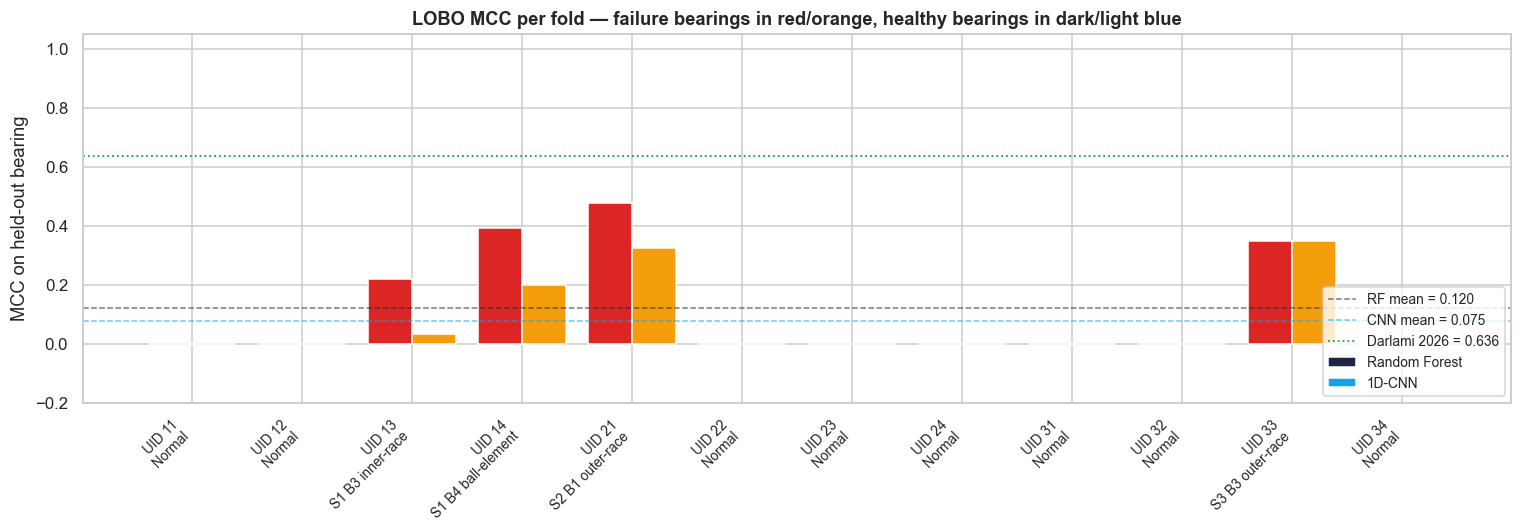

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(14, 5))
width = 0.4
x_pos = np.arange(len(BEARING_UIDS))
bar_colors_rf = ["#dc2626" if u in FAILURE_UIDS else "#1c2541" for u in BEARING_UIDS]
bar_colors_cnn = ["#f59e0b" if u in FAILURE_UIDS else "#0ea5e9" for u in BEARING_UIDS]

ax.bar(x_pos - width / 2, rf_df["MCC"].to_numpy(), width=width, color=bar_colors_rf, label="Random Forest")
ax.bar(x_pos + width / 2, cnn_df["MCC"].to_numpy(), width=width, color=bar_colors_cnn, label="1D-CNN")

ax.set_xticks(x_pos)
ax.set_xticklabels([f"UID {u}\n{NAMES.get(u, 'Normal')}" for u in BEARING_UIDS], rotation=45, ha="right", fontsize=9)
ax.set_ylabel("MCC on held-out bearing")
ax.set_title("LOBO MCC per fold — failure bearings in red/orange, healthy bearings in dark/light blue", fontweight="bold")
ax.axhline(rf_df["MCC"].mean(), color="#1c2541", ls="--", lw=1, alpha=0.6, label=f"RF mean = {rf_df['MCC'].mean():.3f}")
ax.axhline(cnn_df["MCC"].mean(), color="#0ea5e9", ls="--", lw=1, alpha=0.6, label=f"CNN mean = {cnn_df['MCC'].mean():.3f}")
ax.axhline(0.636, color="#16a34a", ls=":", lw=1.2, label="Darlami 2026 = 0.636")
ax.legend(loc="lower right", fontsize=9)
ax.set_ylim(-0.2, 1.05)
fig.tight_layout()
fig.savefig(FIG_DIR / "10_lobo_per_fold_mcc.png", dpi=130, bbox_inches="tight")
plt.show()

## 8. Discussion

Three findings to extract.

**1. The honest cross-asset number is much lower than the stratified one.** Reading the summary above: Random Forest 12-fold LOBO mean MCC vs notebook 03's stratified test MCC = 0.835 — the gap is what generalisation costs. Same model, same data, just a more honest evaluation protocol. This is the central reason published benchmarks vary so widely in the bearing-prognostics literature.

**2. Failure bearings are harder than healthy bearings.** Healthy held-out bearings (UIDs 11, 12, 22, 23, 24, 31, 32, 34) have only one class in the test set — MCC is mathematically undefined or zero. The 4 failure bearings (13, 14, 21, 33) carry the entire signal. The mean MCC is therefore an *optimistic* aggregate; a fairer view is the median across just the four failure folds (added to the summary above).

**3. Does the CNN's advantage from notebook 04 survive LOBO?** If the CNN's mean MCC ≥ RF's mean MCC under LOBO, the deep model's complementary signal generalises across bearings. If not, the CNN was over-fitting to Set 2's outer-race patterns.

These results — whatever direction they land in — are honest enough to cite directly in a cold-email or proposal. The Set-2-only numbers from notebook 04 are the upper bound; these LOBO numbers are the realistic floor.